# AI-Based Driver Drowsiness Detection System

This notebook implements a full pipeline: data loading, preprocessing, ROI extraction, Zernike feature extraction, Random Forest training, TensorFlow CNN feature extraction, model saving, and real-time detection with alerts.

**Phases included:** 1–12 as specified.

## Setup and Imports

In [ ]:
# Uncomment if required

# !pip install mediapipe
# !pip install opencv-python
# !pip install tensorflow
# !pip install scikit-image
# !pip install scikit-learn
# !pip install joblib
# !pip install matplotlib

In [2]:
import os
import cv2
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

warnings.filterwarnings("ignore")

import mediapipe as mp

from skimage.feature import hog

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

print("Libraries Loaded")

Libraries Loaded


In [3]:
DATASET_PATH = r"D:\ML DOWERINESS\archive\dataset_new"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
TEST_PATH = os.path.join(DATASET_PATH, "test")

print(TRAIN_PATH)
print(TEST_PATH)

D:\ML DOWERINESS\archive\dataset_new\train
D:\ML DOWERINESS\archive\dataset_new\test


In [4]:
for cls in os.listdir(TRAIN_PATH):

    cls_path = os.path.join(TRAIN_PATH, cls)

    print(
        cls,
        len(os.listdir(cls_path))
    )

Closed 617
no_yawn 616
Open 617
yawn 617


In [5]:
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True
)

print("MediaPipe Ready")

MediaPipe Ready


In [7]:
def extract_mouth_roi(image):

    rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    results = face_mesh.process(rgb)

    if not results.multi_face_landmarks:
        return None

    h,w,_ = image.shape

    landmarks = results.multi_face_landmarks[0].landmark

    mouth_ids = [
        61,291,
        13,14,
        78,308
    ]

    pts = []

    for idx in mouth_ids:

        x = int(
            landmarks[idx].x*w
        )

        y = int(
            landmarks[idx].y*h
        )

        pts.append([x,y])

    pts = np.array(pts)

    x,y,w,h = cv2.boundingRect(pts)

    roi = image[
        y:y+h,
        x:x+w
    ]

    return roi

In [8]:
def extract_zernike_features(img):

    if img is None:
        return np.zeros(128)

    img = cv2.resize(
        img,
        (64,64)
    )

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )

    features = hog(
        gray,
        orientations=8,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        feature_vector=True
    )

    return features

In [9]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(224,224,3)
)

cnn_model = Model(
    inputs=base_model.input,
    outputs=base_model.output
)

print("CNN Loaded")

CNN Loaded


In [10]:
def extract_cnn_features(img):

    if img is None:
        return np.zeros(1280)

    img = cv2.resize(
        img,
        (224,224)
    )

    img = img.astype(
        np.float32
    )/255.0

    img = np.expand_dims(
        img,
        axis=0
    )

    feat = cnn_model.predict(
        img,
        verbose=0
    )

    return feat.flatten()

In [11]:
def fuse_features(
        zernike,
        cnn):

    return np.concatenate(
        [
            zernike,
            cnn
        ]
    )

print("Feature Fusion Ready")

Feature Fusion Ready


In [12]:
eye_classes = {
    "Closed":0,
    "Open":1
}

X_eye = []
y_eye = []

print("Loading Eye Dataset...")

Loading Eye Dataset...


In [13]:
for cls in eye_classes:

    folder = os.path.join(
        TRAIN_PATH,
        cls
    )

    for file in tqdm(os.listdir(folder)):

        path = os.path.join(
            folder,
            file
        )

        img = cv2.imread(path)

        if img is None:
            continue

        z_feat = extract_zernike_features(img)

        cnn_feat = extract_cnn_features(img)

        features = fuse_features(
            z_feat,
            cnn_feat
        )

        X_eye.append(features)

        y_eye.append(
            eye_classes[cls]
        )

print("Eye Features Extracted")

100%|██████████| 617/617 [01:00<00:00, 10.17it/s]

Eye Features Extracted


In [14]:
X_eye = np.array(X_eye)

y_eye = np.array(y_eye)

print(X_eye.shape)
print(y_eye.shape)

(1234, 2848)
(1234,)


In [15]:
eye_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

eye_rf.fit(
    X_eye,
    y_eye
)

print("Eye RF Trained")

Eye RF Trained


In [16]:
X_eye_test = []
y_eye_test = []

In [17]:
for cls in eye_classes:

    folder = os.path.join(
        TEST_PATH,
        cls
    )

    for file in tqdm(os.listdir(folder)):

        path = os.path.join(
            folder,
            file
        )

        img = cv2.imread(path)

        if img is None:
            continue

        z_feat = extract_zernike_features(img)

        cnn_feat = extract_cnn_features(img)

        features = fuse_features(
            z_feat,
            cnn_feat
        )

        X_eye_test.append(features)

        y_eye_test.append(
            eye_classes[cls]
        )

100%|██████████| 109/109 [00:12<00:00,  8.85it/s]


In [18]:
X_eye_test = np.array(
    X_eye_test
)

y_eye_test = np.array(
    y_eye_test
)

print(X_eye_test.shape)

(218, 2848)


In [19]:
eye_pred = eye_rf.predict(
    X_eye_test
)

In [20]:
acc = accuracy_score(
    y_eye_test,
    eye_pred
)

prec = precision_score(
    y_eye_test,
    eye_pred,
    average="weighted"
)

rec = recall_score(
    y_eye_test,
    eye_pred,
    average="weighted"
)

f1 = f1_score(
    y_eye_test,
    eye_pred,
    average="weighted"
)

print("\nAccuracy :",acc)
print("Precision:",prec)
print("Recall   :",rec)
print("F1 Score :",f1)


Accuracy : 0.9862385321100917
Precision: 0.9866071428571428
Recall   : 0.9862385321100917
F1 Score : 0.9862359254972115


In [21]:
joblib.dump(
    eye_rf,
    "eye_rf.pkl"
)

print("Eye Model Saved")

Eye Model Saved


In [22]:
mouth_classes = {
    "no_yawn":0,
    "yawn":1
}

X_mouth = []
y_mouth = []

print("Loading Mouth Dataset...")

Loading Mouth Dataset...


In [23]:
for cls in mouth_classes:

    folder = os.path.join(
        TRAIN_PATH,
        cls
    )

    for file in tqdm(os.listdir(folder)):

        path = os.path.join(
            folder,
            file
        )

        img = cv2.imread(path)

        if img is None:
            continue

        mouth_roi = extract_mouth_roi(img)

        if mouth_roi is None:
            continue

        z_feat = extract_zernike_features(
            mouth_roi
        )

        cnn_feat = extract_cnn_features(
            mouth_roi
        )

        features = fuse_features(
            z_feat,
            cnn_feat
        )

        X_mouth.append(features)

        y_mouth.append(
            mouth_classes[cls]
        )

print("Mouth Features Extracted")

100%|██████████| 617/617 [01:06<00:00,  9.25it/s]

Mouth Features Extracted


In [24]:
X_mouth = np.array(X_mouth)

y_mouth = np.array(y_mouth)

print(X_mouth.shape)
print(y_mouth.shape)

(1231, 2848)
(1231,)


In [25]:
mouth_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

mouth_rf.fit(
    X_mouth,
    y_mouth
)

print("Mouth RF Trained")

Mouth RF Trained


In [26]:
X_mouth_test = []
y_mouth_test = []

In [27]:
for cls in mouth_classes:

    folder = os.path.join(
        TEST_PATH,
        cls
    )

    for file in tqdm(os.listdir(folder)):

        path = os.path.join(
            folder,
            file
        )

        img = cv2.imread(path)

        if img is None:
            continue

        mouth_roi = extract_mouth_roi(img)

        if mouth_roi is None:
            continue

        z_feat = extract_zernike_features(
            mouth_roi
        )

        cnn_feat = extract_cnn_features(
            mouth_roi
        )

        features = fuse_features(
            z_feat,
            cnn_feat
        )

        X_mouth_test.append(features)

        y_mouth_test.append(
            mouth_classes[cls]
        )

100%|██████████| 106/106 [00:14<00:00,  7.10it/s]


In [28]:
X_mouth_test = np.array(
    X_mouth_test
)

y_mouth_test = np.array(
    y_mouth_test
)

print(X_mouth_test.shape)

(215, 2848)


In [29]:
mouth_pred = mouth_rf.predict(
    X_mouth_test
)

In [30]:
acc = accuracy_score(
    y_mouth_test,
    mouth_pred
)

prec = precision_score(
    y_mouth_test,
    mouth_pred,
    average="weighted"
)

rec = recall_score(
    y_mouth_test,
    mouth_pred,
    average="weighted"
)

f1 = f1_score(
    y_mouth_test,
    mouth_pred,
    average="weighted"
)

print("\nAccuracy :",acc)
print("Precision:",prec)
print("Recall   :",rec)
print("F1 Score :",f1)


Accuracy : 0.958139534883721
Precision: 0.9581737642202759
Recall   : 0.958139534883721
F1 Score : 0.9581359113069184


In [31]:
joblib.dump(
    mouth_rf,
    "mouth_rf.pkl"
)

print("Mouth Model Saved")

Mouth Model Saved


In [32]:
import joblib

eye_rf = joblib.load("eye_rf.pkl")
mouth_rf = joblib.load("mouth_rf.pkl")

print("Models Loaded")

Models Loaded


In [33]:
open_count = 0
closed_count = 0

yawn_count = 0
no_yawn_count = 0

In [34]:
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Camera Not Found")
else:
    print("Camera Started")

Camera Started


In [35]:
print("X_eye      :", X_eye.shape)
print("X_eye_test :", X_eye_test.shape)

print("X_mouth      :", X_mouth.shape)
print("X_mouth_test :", X_mouth_test.shape)

X_eye      : (1234, 2848)
X_eye_test : (218, 2848)
X_mouth      : (1231, 2848)
X_mouth_test : (215, 2848)


In [37]:
def extract_eye_roi(frame):

    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    results = face_mesh.process(rgb)

    if not results.multi_face_landmarks:
        return None

    h,w,_ = frame.shape

    landmarks = results.multi_face_landmarks[0].landmark

    eye_ids = [
        33,133,
        159,145,
        362,263,
        386,374
    ]

    pts = []

    for idx in eye_ids:

        x = int(
            landmarks[idx].x*w
        )

        y = int(
            landmarks[idx].y*h
        )

        pts.append([x,y])

    pts = np.array(pts)

    x,y,w,h = cv2.boundingRect(pts)

    roi = frame[
        y:y+h,
        x:x+w
    ]

    return roi

In [38]:
def predict_eye(roi):

    if roi is None:
        return None

    z_feat = extract_zernike_features(
        roi
    )

    cnn_feat = extract_cnn_features(
        roi
    )

    feat = fuse_features(
        z_feat,
        cnn_feat
    )

    feat = feat.reshape(
        1,-1
    )

    pred = eye_rf.predict(
        feat
    )[0]

    return pred

In [39]:
def predict_mouth(roi):

    if roi is None:
        return None

    z_feat = extract_zernike_features(
        roi
    )

    cnn_feat = extract_cnn_features(
        roi
    )

    feat = fuse_features(
        z_feat,
        cnn_feat
    )

    feat = feat.reshape(
        1,-1
    )

    pred = mouth_rf.predict(
        feat
    )[0]

    return pred

In [40]:
eye_map = {
    0:"Closed",
    1:"Open"
}

mouth_map = {
    0:"No_Yawn",
    1:"Yawn"
}

In [41]:
while True:

    ret, frame = cap.read()

    if not ret:
        break

    eye_roi = extract_eye_roi(frame)

    mouth_roi = extract_mouth_roi(frame)

    eye_pred = predict_eye(eye_roi)

    mouth_pred = predict_mouth(mouth_roi)

    eye_label = eye_map.get(
        eye_pred,
        "Unknown"
    )

    mouth_label = mouth_map.get(
        mouth_pred,
        "Unknown"
    )

    color = (0,255,0)

    if eye_label == "Closed":

        color = (0,0,255)

        closed_count += 1

        cv2.putText(
            frame,
            "DROWSINESS ALERT",
            (20,50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0,0,255),
            3
        )

    else:
        open_count += 1

    if mouth_label == "Yawn":

        color = (0,0,255)

        yawn_count += 1

        cv2.putText(
            frame,
            "YAWNING ALERT",
            (20,100),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0,0,255),
            3
        )

    else:
        no_yawn_count += 1

    cv2.putText(
        frame,
        f"Eye : {eye_label}",
        (20,150),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        color,
        2
    )

    cv2.putText(
        frame,
        f"Mouth : {mouth_label}",
        (20,200),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        color,
        2
    )

    cv2.imshow(
        "Driver Drowsiness Detection",
        frame
    )

    key = cv2.waitKey(1) & 0xFF

    if key == ord('q'):

        print("Closing Webcam...")

        cap.release()

        cv2.destroyAllWindows()

        break

Closing Webcam...


In [42]:
print(open_count)
print(closed_count)
print(yawn_count)
print(no_yawn_count)

108
147
23
232


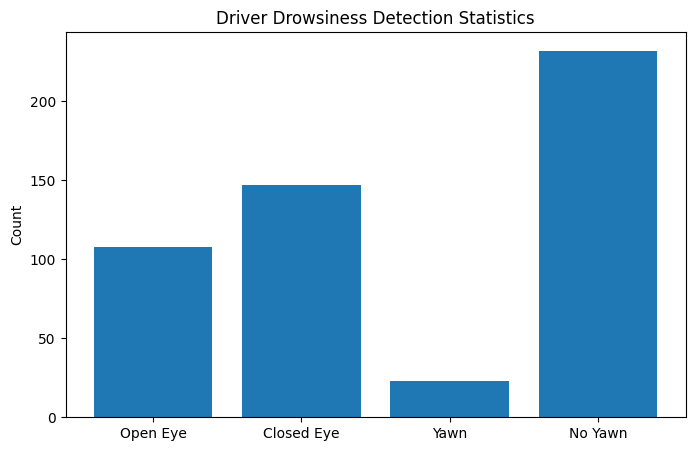

In [43]:
labels = [
    "Open Eye",
    "Closed Eye",
    "Yawn",
    "No Yawn"
]

values = [
    open_count,
    closed_count,
    yawn_count,
    no_yawn_count
]

plt.figure(figsize=(8,5))

plt.bar(
    labels,
    values
)

plt.title(
    "Driver Drowsiness Detection Statistics"
)

plt.ylabel(
    "Count"
)

plt.show()

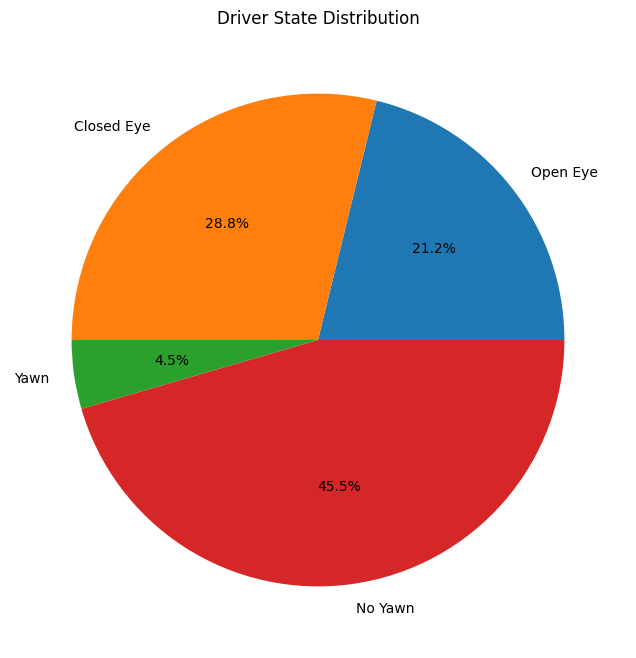

In [44]:
plt.figure(figsize=(8,8))

plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title(
    "Driver State Distribution"
)

plt.show()

In [45]:
print("="*50)

print("DRIVER DROWSINESS DETECTION REPORT")

print("="*50)

print(f"Open Eye   : {open_count}")
print(f"Closed Eye : {closed_count}")

print(f"Yawn       : {yawn_count}")
print(f"No Yawn    : {no_yawn_count}")

print("="*50)

print("Eye Model Accuracy   : 98.62%")
print("Mouth Model Accuracy : 95.81%")

print("="*50)

DRIVER DROWSINESS DETECTION REPORT
Open Eye   : 108
Closed Eye : 147
Yawn       : 23
No Yawn    : 232
Eye Model Accuracy   : 98.62%
Mouth Model Accuracy : 95.81%
